# ARIMAX (AutoRegressive Integrated Moving Average with Exogenous Variables)

ARIMAX is an extension of the traditional ARIMA model. While ARIMA models rely solely on the past values of the target variable to make forecasts, ARIMAX introduces **Exogenous Variables**—external factors that influence the target variable.

### Core Components:
1. **Past values of the target variable** (Internal patterns/trends)
2. **External influencing variables** (Exogenous variables, or `exog`)

**Example:**
* **Target Variable ($Y$):** Sales
* **Exogenous Variables ($X$):** Advertising spend, Temperature, Holiday effects

In [1]:
# STEP 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ARIMA/SARIMAX model from statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Metrics
from sklearn.metrics import mean_absolute_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## STEP 2: Create Sample Dataset
We will create a dummy dataset where `sales` is our target variable, and `ads` (advertising spend) is our external factor impacting those sales.

In [2]:
# Create sample dictionary
data = {
    'sales': [312, 458, 521, 689, 745,
          398, 566, 812, 467, 290,
          355, 428, 610, 502, 731],

    'ads': [8, 12, 18, 25, 30,
        15, 22, 40, 19, 10,
        14, 17, 28, 24, 35]
}

# Convert to DataFrame
df = pd.DataFrame(data)
df.head()

,sales,ads
0,312,8
1,458,12
2,521,18
3,689,25
4,745,30


## STEP 3: Visualize Data
Visualizing the time series lets us see if there is an underlying trend or seasonality in the data before modeling.

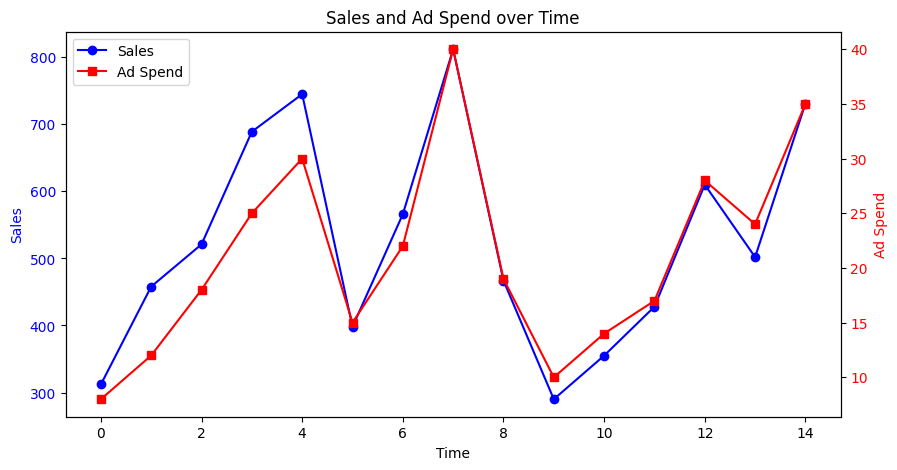

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df['sales'], marker='o', label='Sales', color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis
ax2.plot(df['ads'], marker='s', label='Ad Spend', color='red')
ax2.set_ylabel('Ad Spend', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Sales and Ad Spend over Time")

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## STEP 4 & 5: Split Data and Separate Variables
We will use the first 12 observations for training the model and reserve the last 3 observations for testing its forecasting accuracy.

* **$y$** = Target variable (`sales`)
* **$X$** = External/Exogenous variables (`ads`)

In [4]:
# Split Data into Train/Test sets
train = df[:12]
test = df[12:]

print(f"Training shape: {train.shape}")
print(f"Testing shape: {test.shape}\n")

# Separate Target (y) and Exogenous (X) variables
y_train = train['sales']
x_train = train[['ads']]

y_test = test['sales']
x_test = test[['ads']]

Training shape: (12, 2)
Testing shape: (3, 2)



## STEP 6: Build and Train ARIMAX Model
We configure the `SARIMAX` function by passing the exogenous training data into the `exog` parameter.

The `order=(p, d, q)` represents:
* **p**: Autoregressive terms (past values)
* **d**: Differencing (to make data stationary)
* **q**: Moving average terms (past errors)

In [5]:
# Define model configuration
model = SARIMAX(
    y_train,
    exog=x_train,
    order=(1, 1, 1)
)

# Fit the model
model_fit = model.fit(disp=False)
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   12
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -56.113
Date:                Thu, 28 May 2026   AIC                            120.226
Time:                        17:27:03   BIC                            121.818
Sample:                             0   HQIC                           119.223
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ads           18.2688      1.899      9.619      0.000      14.546      21.991
ar.L1         -0.6359      0.977     -0.651      0.515      -2.550       1.279
ma.L1          0.0356      1.829      0.019      0.9

## STEP 7: Forecast Future Values
 **Crucial Rule:** When forecasting future timelines with an ARIMAX model, you **must** supply the future values of your exogenous variables (`x_test`) for that same period.

In [6]:
# Predict future values
predictions = model_fit.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=x_test
)

print("Predicted values:")
print(predictions)

Predicted values:
12    617.873351
13    551.845662
14    748.321007
Name: predicted_mean, dtype: float64


## STEP 8 & 9: Evaluate and Plot Results
Let's align our actual validation values side-by-side with our model predictions and plot them visually.

    Actual   Predicted
12     610  617.873351
13     502  551.845662
14     731  748.321007


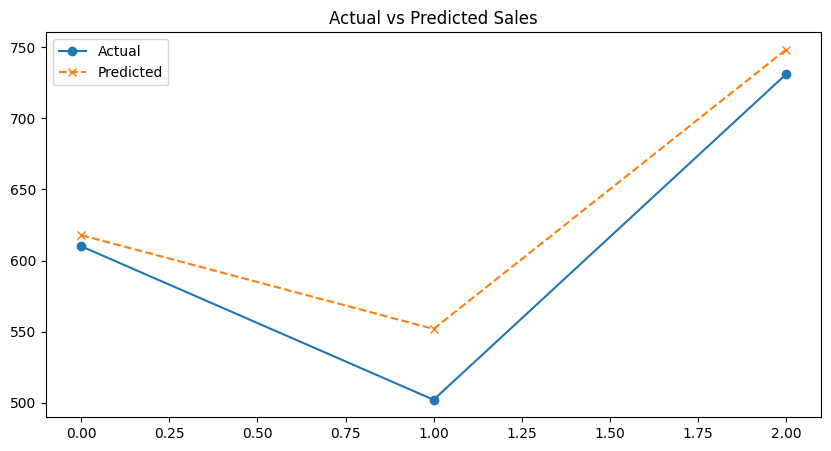

In [7]:
# Compare Actual vs Predicted
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})
print(result)

# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(predictions.values, label='Predicted', marker='x', linestyle='--')
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

## STEP 10: Performance Evaluation
We measure performance using Mean Absolute Error (MAE). Lower MAE scores indicate better predictive accuracy.

In [8]:
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 25.01


---
##  Quick Theory Cheat-Sheet

* **ARIMA:** Uses only past target values ($Y_{t-1}, Y_{t-2}...$)
* **ARIMAX:** ARIMA + External factors ($X$)
* **SARIMA:** ARIMA + Seasonality (e.g., spikes every December)
* **SARIMAX:** SARIMA + External factors ($X$)

### Pipeline Flow Summary
1. **Collect Data** (Time series + External factors)
2. **Split Data** into Train/Test sets
3. **Separate** target variables ($y$) from exogenous variables ($X$)
4. **Define hyperparameters** $(p, d, q)$
5. **Train** the model using `exog=x_train`
6. **Forecast** the future using `exog=x_test`
7. **Evaluate** results via errors (MAE/RMSE) and plots.